# Experiments 
In this notebook we'll develop some experiments about the performance of LSTM architecture vs TimesFM.

__Content__:
1. Load data and preparate for training
2. Train LSTM
3. Train TimesFM
4. Save results and discussion


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from matplotlib.ticker import MaxNLocator

loss_folder = 'C:/Users/criju/Documents/Codigos Tesis/loss_plots_3'
os.makedirs(loss_folder, exist_ok=True)

es_cb = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

## 1. Train LSTM 
Now we'll train LSTM with 3 windows sizes (7,14,21), 2 different forecast horizon (15,30) and for each interval we add the previous one.

In [18]:
# Load the dataset
df =  pd.read_csv('C:/Users/criju/Documents/Codigos Tesis/data/serie.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Functions for data processing and model building
def create_intervals(df):
    """
    Divide un DataFrame en 8 intervalos regulares basados en la columna 'Fecha',
    grafica los datos y devuelve los intervalos.
    """
    fecha_min = df['Fecha'].min()
    fecha_max = df['Fecha'].max()
    bins = pd.date_range(start=fecha_min, end=fecha_max, periods=9)  # 9 puntos para generar 8 intervalos
    df['Intervalo'] = pd.cut(df['Fecha'], bins=bins, include_lowest=True, right=False)
    intervalos_ordenados = sorted(df['Intervalo'].dropna().unique(), key=lambda x: x.left)
    return intervalos_ordenados

def build_lstm_model(window_size):
    model = Sequential([
        LSTM(32, activation='relu', input_shape=(window_size, 1), dropout=0.2),
        Dense(32),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def create_windows(data, window_size):
    """
    Genera secuencias (ventanas) a partir de la serie de tiempo.
    
    Args:
        data (np.array): Valores escalados de la serie.
        window_size (int): Longitud de la ventana.
        
    Returns:
        tuple: Arrays (x, y) donde x son las secuencias y y el valor a predecir.
    """
    x = []
    y = []
    for i in range(len(data) - window_size):
        x.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(x), np.array(y)

def smape(y_true, y_pred, eps=1e-8):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return 100 * np.mean(numerator / (denominator + eps))

In [19]:
# Review the numbers of parameters of LSTM
model = build_lstm_model(window_size=7)
model.summary()

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train for windows size = 7


Iteración 1: Mejor época = 20, Loss = 0.0293
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Acumulando intervalos 1 a 1: MAE = 108.53, MSE = 21740.22


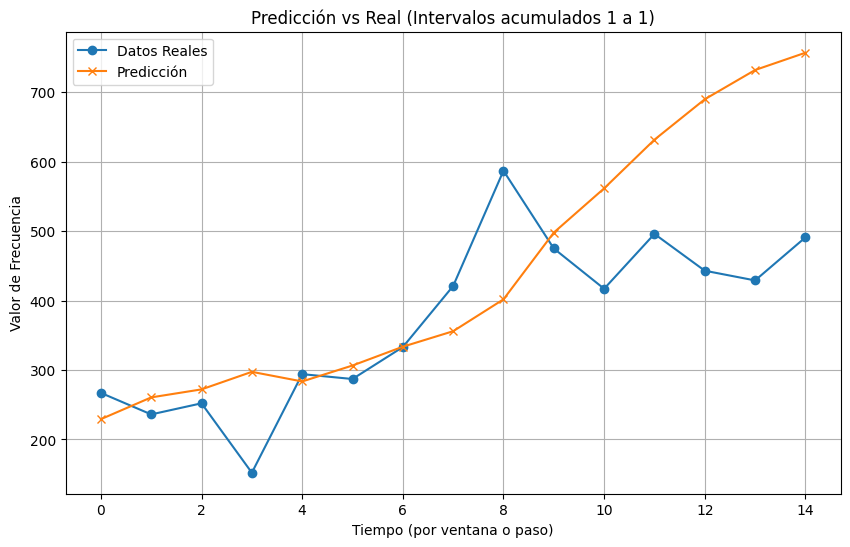

Iteración 2: Mejor época = 14, Loss = 0.2017
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 2: MAE = 107.53, MSE = 18197.20


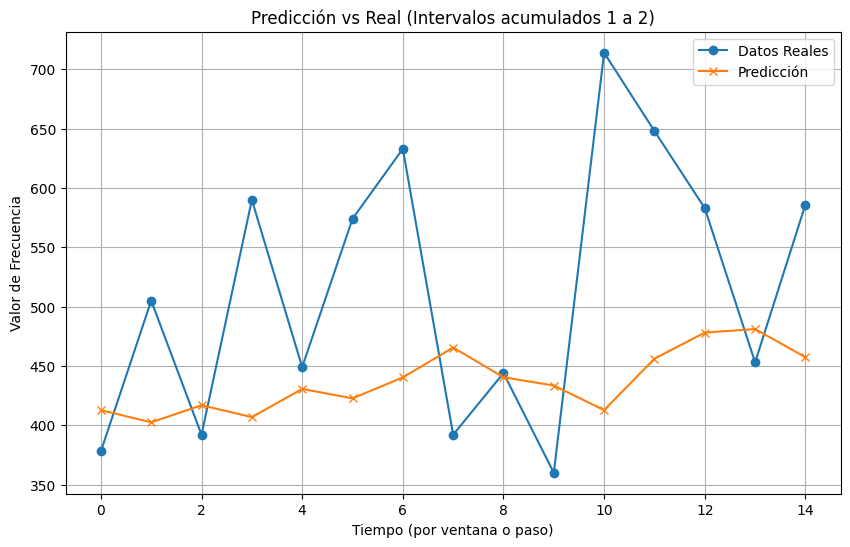

Iteración 3: Mejor época = 2, Loss = 0.1664
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 3: MAE = 283.57, MSE = 129816.71


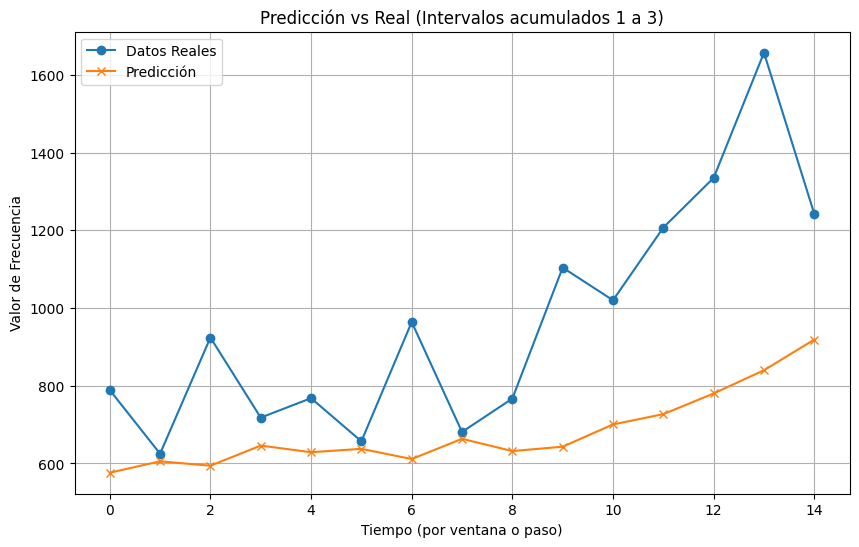

Iteración 4: Mejor época = 2, Loss = 0.2219
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Acumulando intervalos 1 a 4: MAE = 98.78, MSE = 9795.14


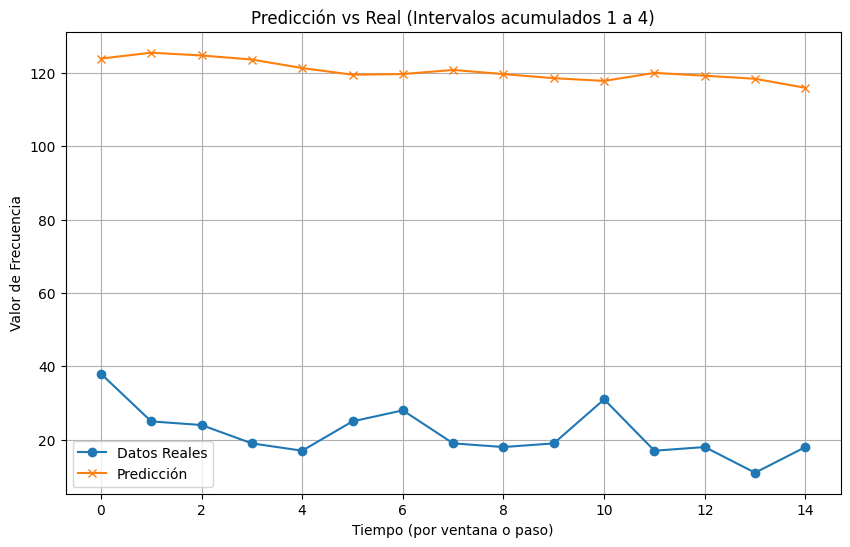

Iteración 5: Mejor época = 2, Loss = 0.1988
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 5: MAE = 97.28, MSE = 12147.49


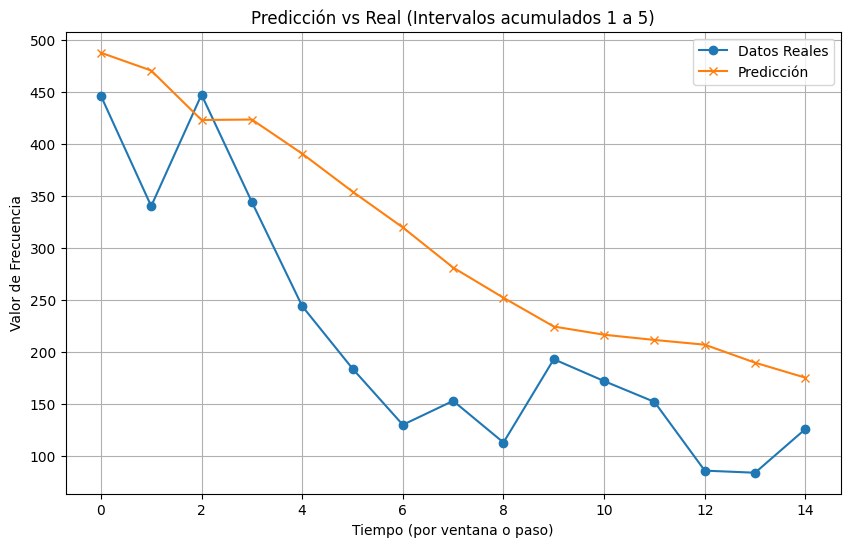

Iteración 6: Mejor época = 14, Loss = 0.2039
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 6: MAE = 30.82, MSE = 1209.96


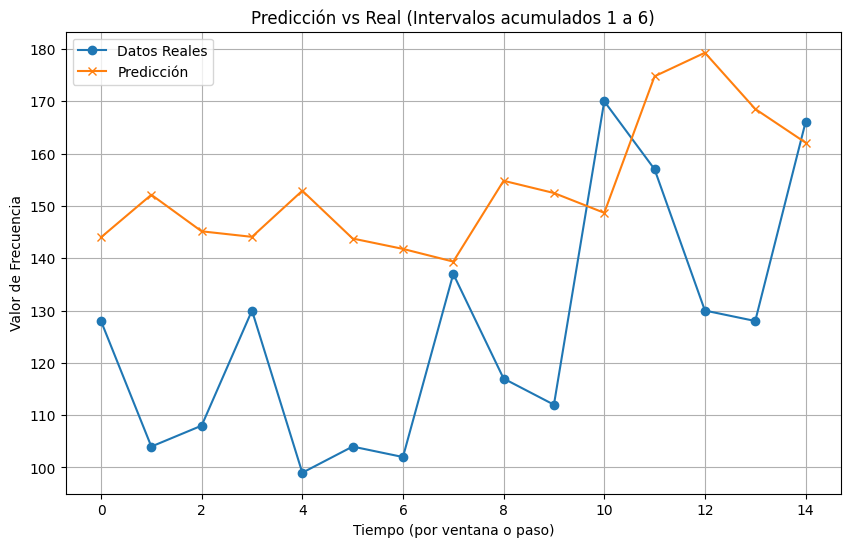

Iteración 7: Mejor época = 9, Loss = 0.1793
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 7: MAE = 38.10, MSE = 1616.15


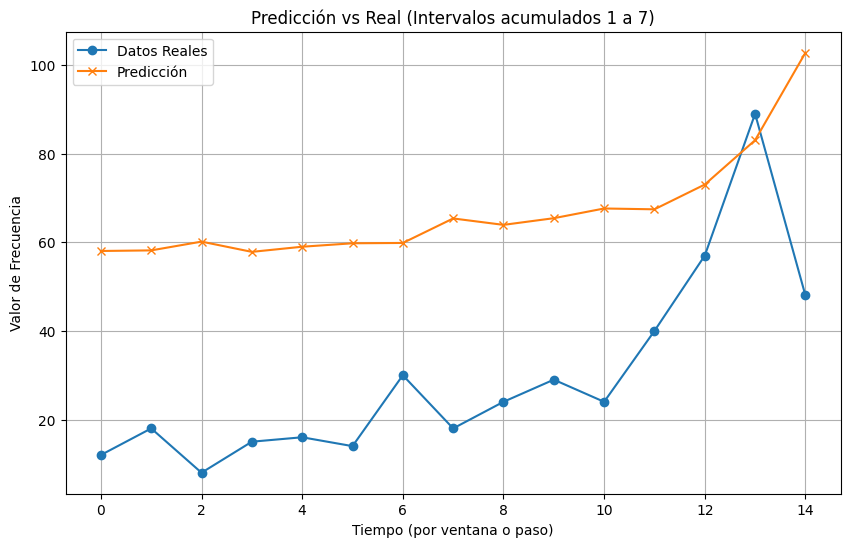

Iteración 8: Mejor época = 6, Loss = 0.2188
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 8: MAE = 65.79, MSE = 4337.10


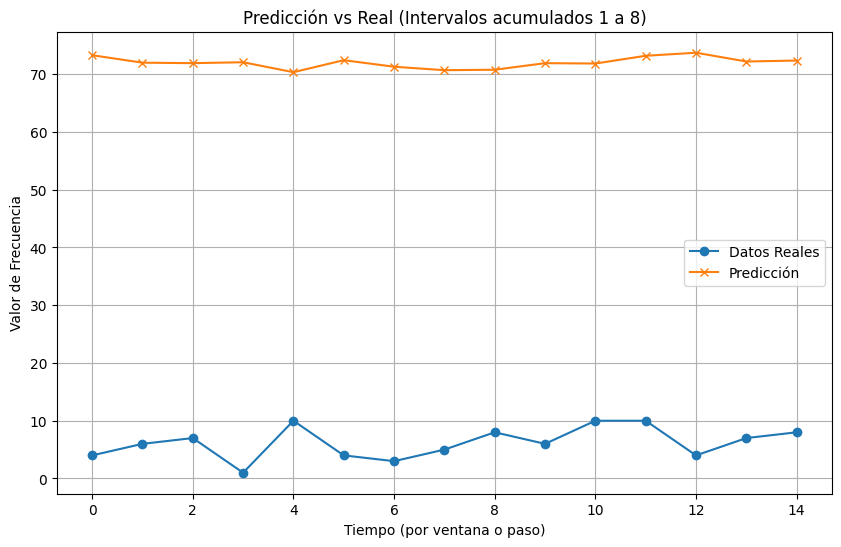


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1  108.534571   21740.219886   23.923286
1      Intervalos 1 a 2  107.526347   18197.197642   21.323489
2      Intervalos 1 a 3  283.571696  129816.711392   31.022942
3      Intervalos 1 a 4   98.779461    9795.144584  139.503021
4      Intervalos 1 a 5   97.280864   12147.485494   43.949480
5      Intervalos 1 a 6   30.816163    1209.963727   22.820384
6      Intervalos 1 a 7   38.095512    1616.146993   89.669224
7      Intervalos 1 a 8   65.789246    4337.095907  168.670586


In [20]:
# Parameters
WINDOW_SIZE = 7  
HORIZONTE = 15 
EPOCHS = 50 
BATCH_SIZE = 16     
intervalos_ordenados = create_intervals(df)

resultados = [] 

# Inicializamos el escalador (se ajustará en cada iteración)
# scaler = MinMaxScaler(feature_range=(0, 1))

scaler = StandardScaler()

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"7_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_5/lstm_7_15.csv', index=False)

Iteración 1: Mejor época = 46, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Acumulando intervalos 1 a 1: MAE = 128.52, MSE = 52636.13


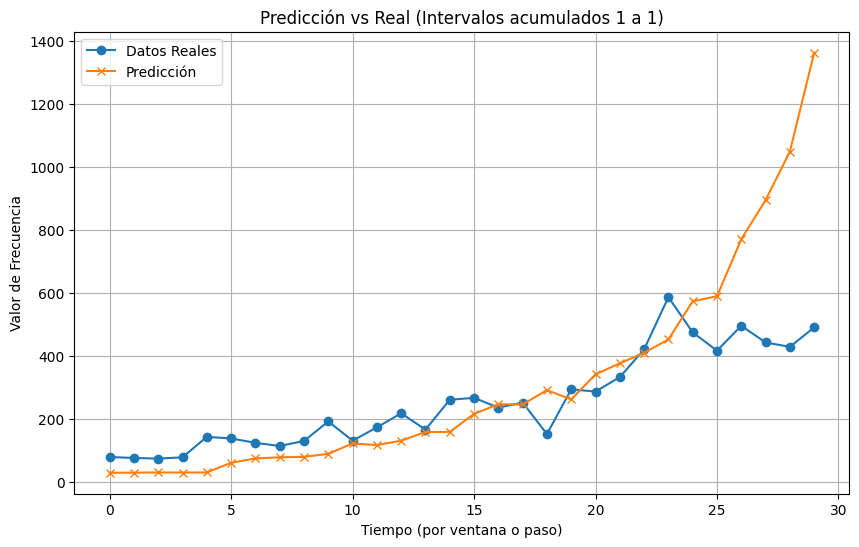

Iteración 2: Mejor época = 15, Loss = 0.2332
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 2: MAE = 86.35, MSE = 12856.54


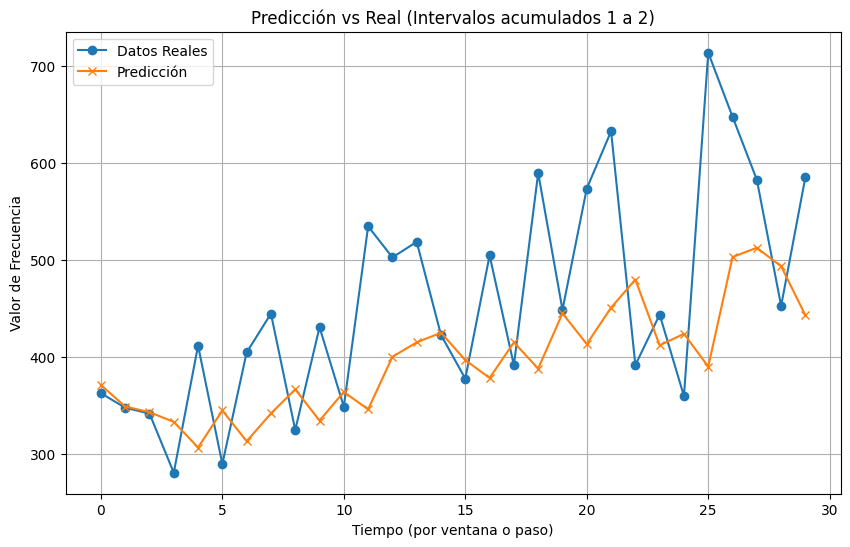

Iteración 3: Mejor época = 8, Loss = 0.1637
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 3: MAE = 210.64, MSE = 80640.93


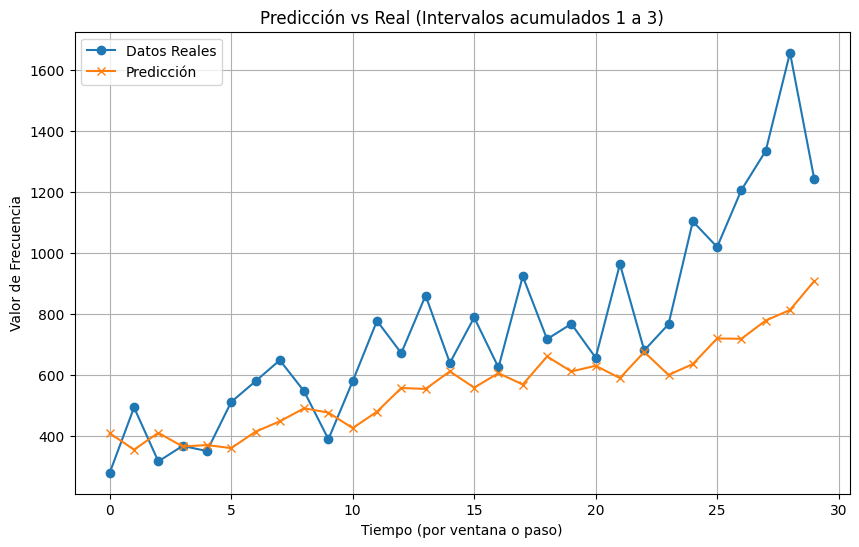

Iteración 4: Mejor época = 2, Loss = 0.2171
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Acumulando intervalos 1 a 4: MAE = 76.40, MSE = 5870.11


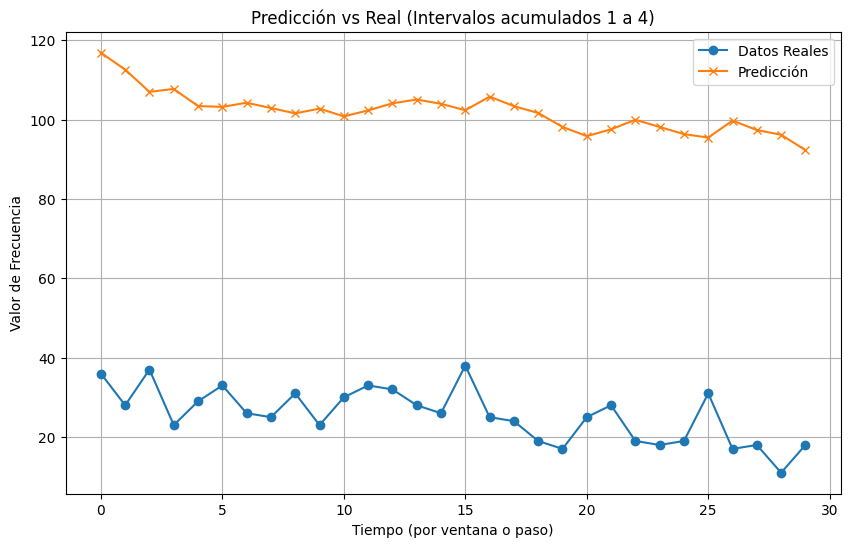

Iteración 5: Mejor época = 4, Loss = 0.1617
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 5: MAE = 106.03, MSE = 17603.68


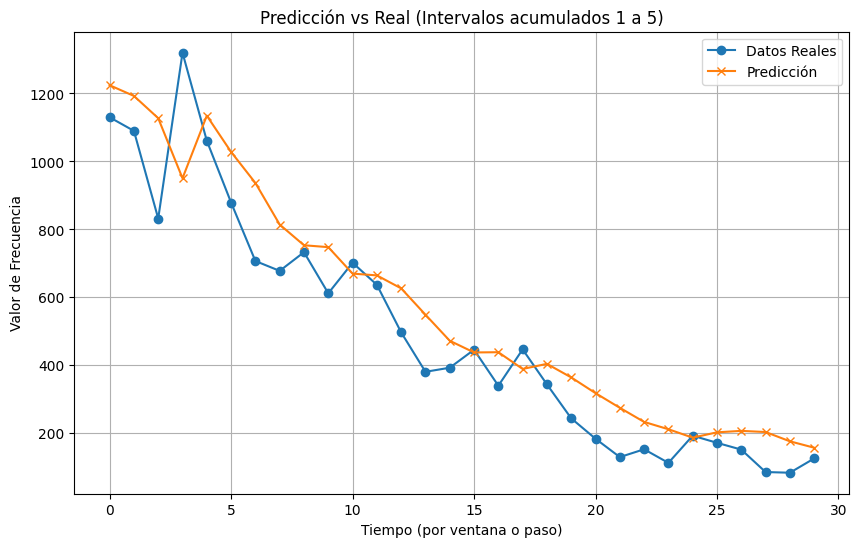

Iteración 6: Mejor época = 12, Loss = 0.1820
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 6: MAE = 41.36, MSE = 2031.66


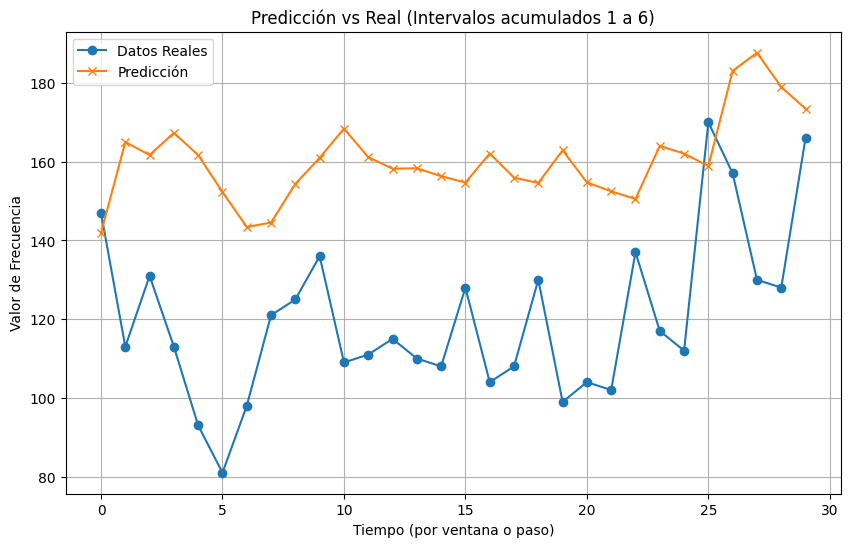

Iteración 7: Mejor época = 8, Loss = 0.2037
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 7: MAE = 54.59, MSE = 3118.21


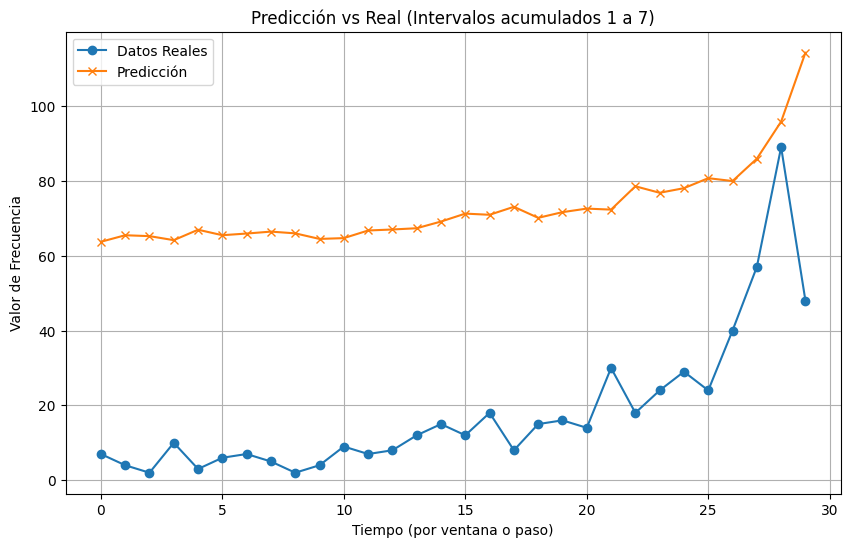

Iteración 8: Mejor época = 1, Loss = 0.1976
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 8: MAE = 38.61, MSE = 1500.67


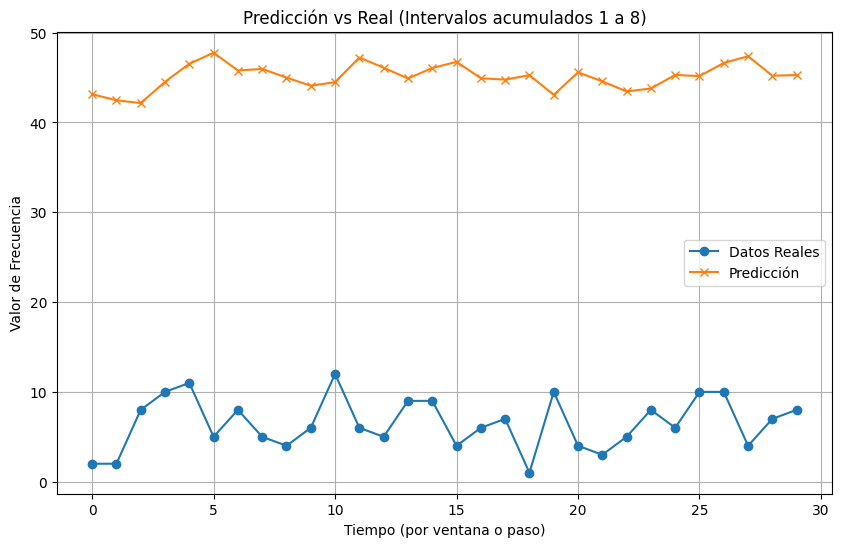


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1  128.517860  52636.134205   47.479405
1      Intervalos 1 a 2   86.354743  12856.536940   19.076064
2      Intervalos 1 a 3  210.642722  80640.931374   28.831289
3      Intervalos 1 a 4   76.395461   5870.107319  120.844915
4      Intervalos 1 a 5  106.028018  17603.679109   26.883307
5      Intervalos 1 a 6   41.358231   2031.656514   30.395000
6      Intervalos 1 a 7   54.591498   3118.210281  132.691317
7      Intervalos 1 a 8   38.612376   1500.670488  150.667035


In [21]:
# Parameters
WINDOW_SIZE = 7 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
#scaler = MinMaxScaler(feature_range=(0, 1))

scaler = StandardScaler()

for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"7_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_5/lstm_7_30.csv', index=False)

### Train for windows size = 14

Iteración 1: Mejor época = 19, Loss = 0.0249
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Acumulando intervalos 1 a 1: MAE = 66.50, MSE = 7963.03


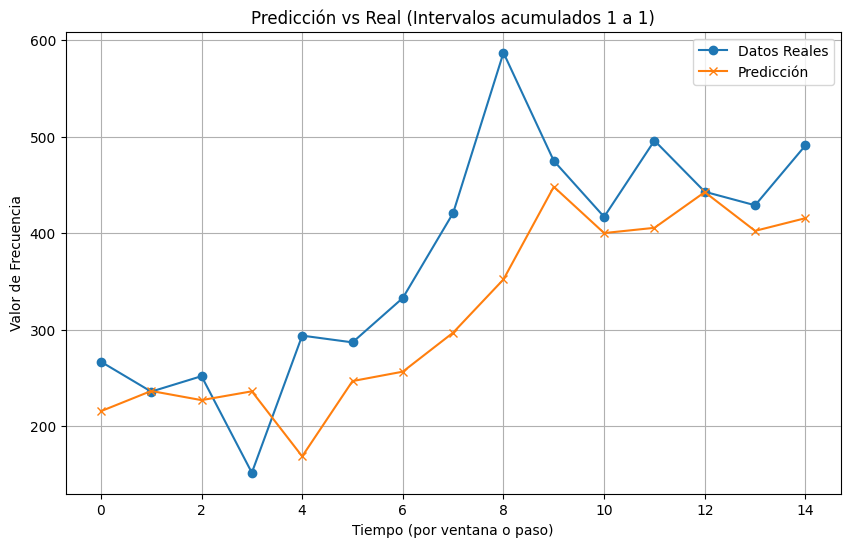

Iteración 2: Mejor época = 5, Loss = 0.2264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Acumulando intervalos 1 a 2: MAE = 108.84, MSE = 18266.44


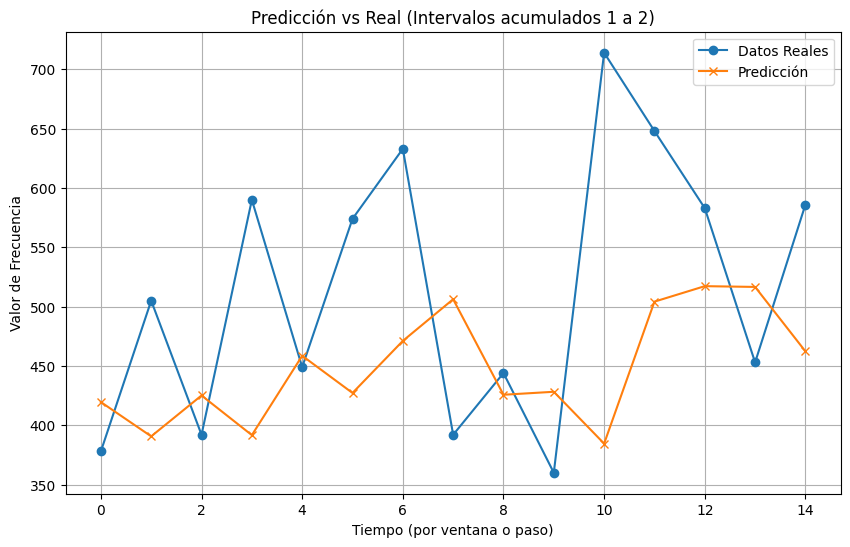

Iteración 3: Mejor época = 3, Loss = 0.1883
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Acumulando intervalos 1 a 3: MAE = 262.06, MSE = 112757.68


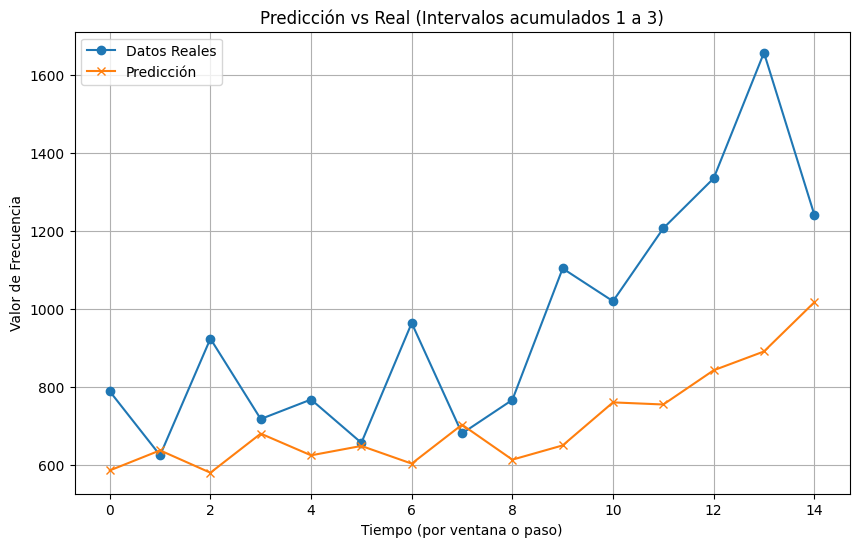

Iteración 4: Mejor época = 3, Loss = 0.1938
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Acumulando intervalos 1 a 4: MAE = 73.90, MSE = 5500.62


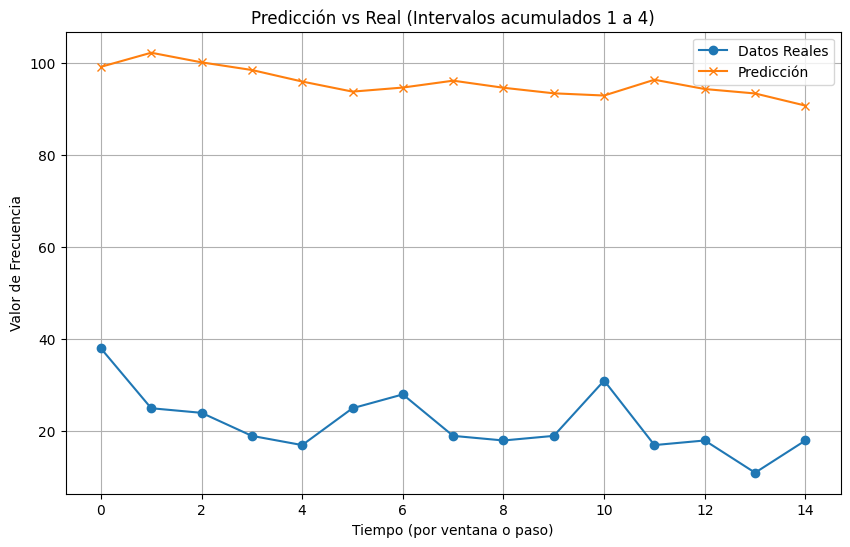

Iteración 5: Mejor época = 3, Loss = 0.1778
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Acumulando intervalos 1 a 5: MAE = 79.59, MSE = 8695.15


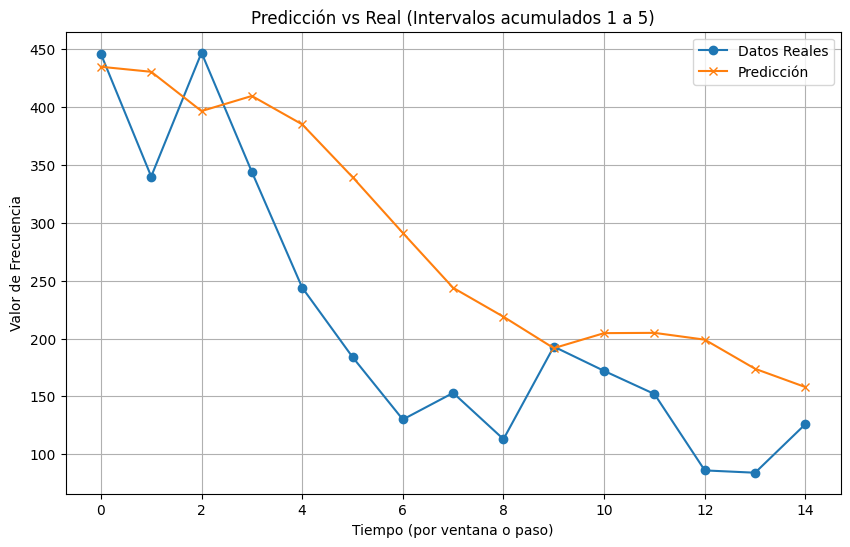

Iteración 6: Mejor época = 9, Loss = 0.1777
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Acumulando intervalos 1 a 6: MAE = 51.36, MSE = 3094.98


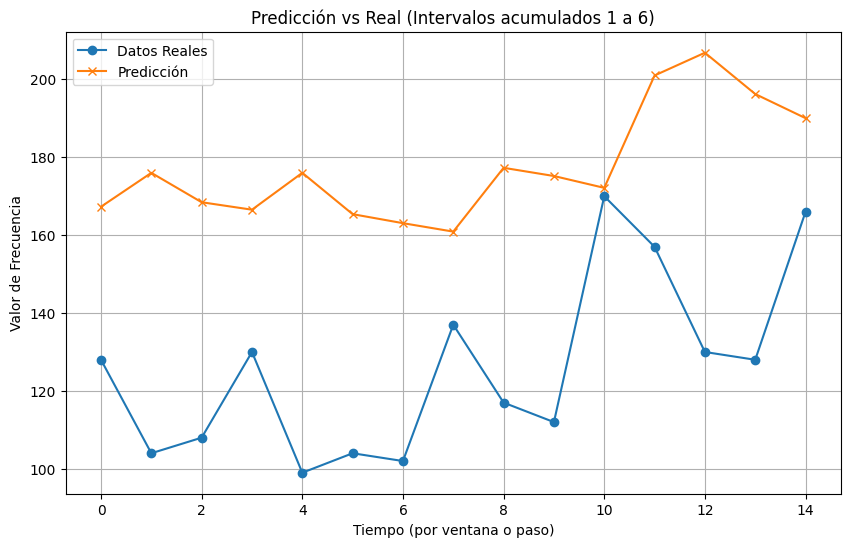

Iteración 7: Mejor época = 8, Loss = 0.1771
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 7: MAE = 41.80, MSE = 1959.47


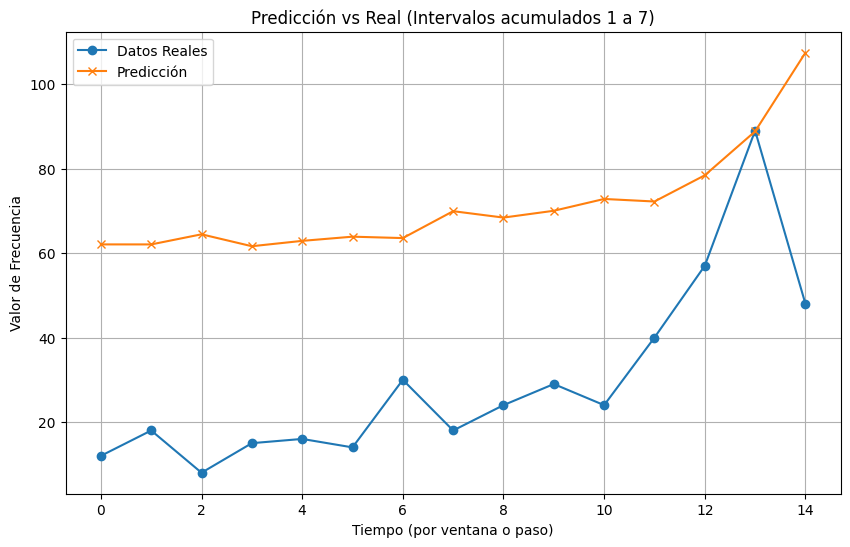

Iteración 8: Mejor época = 4, Loss = 0.2081
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 8: MAE = 51.69, MSE = 2680.59


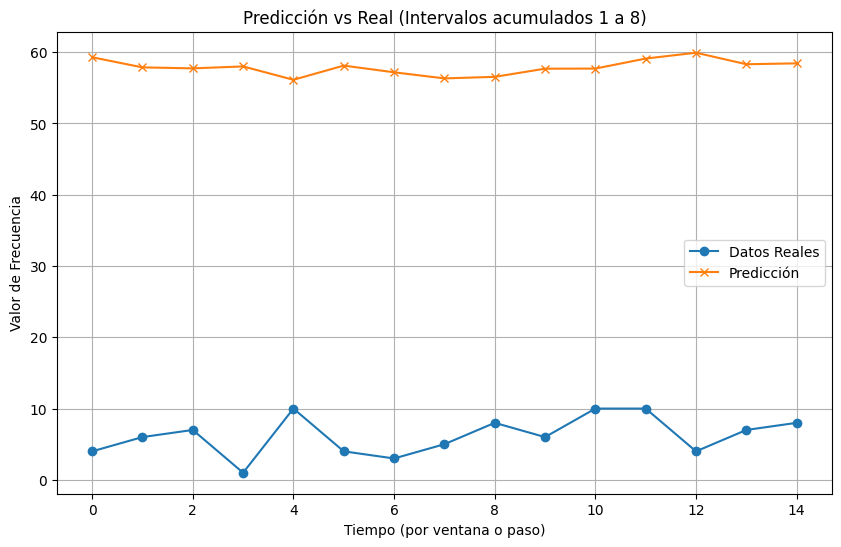


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   66.495576    7963.033713   20.519240
1      Intervalos 1 a 2  108.841331   18266.442370   21.718630
2      Intervalos 1 a 3  262.064766  112757.684156   28.519318
3      Intervalos 1 a 4   73.903148    5500.619648  126.822039
4      Intervalos 1 a 5   79.592660    8695.149952   37.663737
5      Intervalos 1 a 6   51.360038    3094.981776   34.810770
6      Intervalos 1 a 7   41.801787    1959.468759   93.681563
7      Intervalos 1 a 8   51.685900    2680.594164  161.864923


In [22]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
# scaler = MinMaxScaler(feature_range=(0, 1))

scaler = StandardScaler()

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"14_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_5/lstm_14_15.csv', index=False)

Iteración 1: Mejor época = 19, Loss = 0.0055
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Acumulando intervalos 1 a 1: MAE = 91.78, MSE = 12082.63


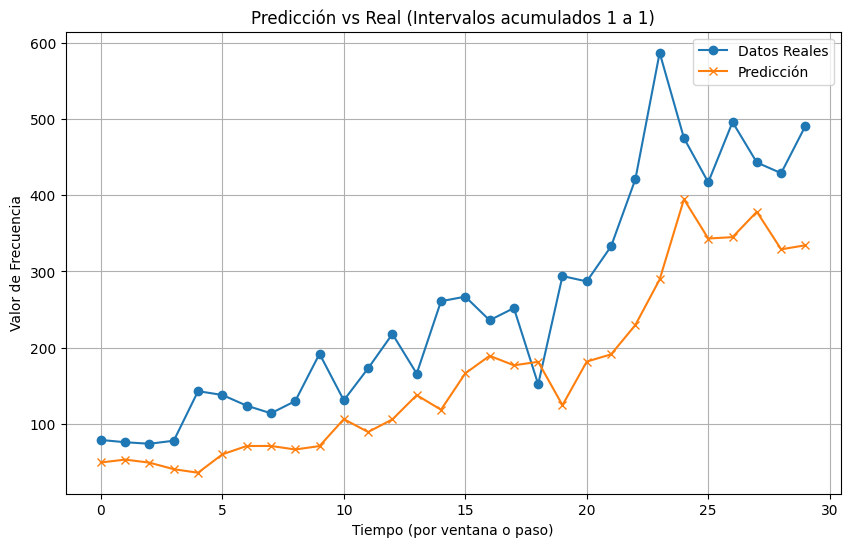

Iteración 2: Mejor época = 5, Loss = 0.2344
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Acumulando intervalos 1 a 2: MAE = 90.96, MSE = 14605.49


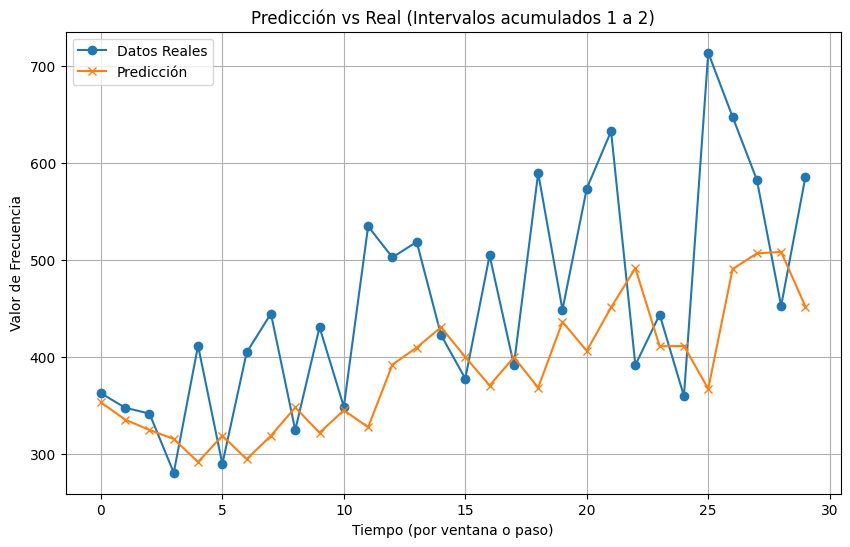

Iteración 3: Mejor época = 4, Loss = 0.1641
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Acumulando intervalos 1 a 3: MAE = 198.20, MSE = 70278.25


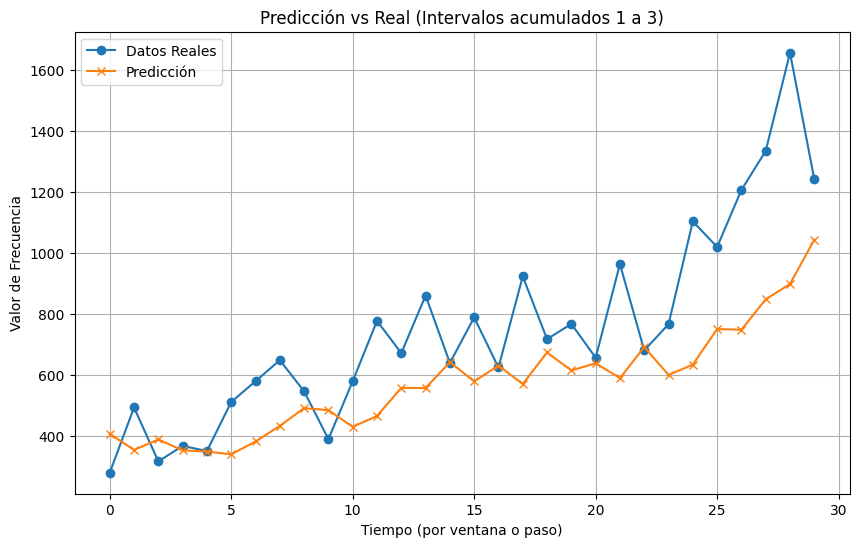

Iteración 4: Mejor época = 9, Loss = 0.2248
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Acumulando intervalos 1 a 4: MAE = 69.04, MSE = 4798.95


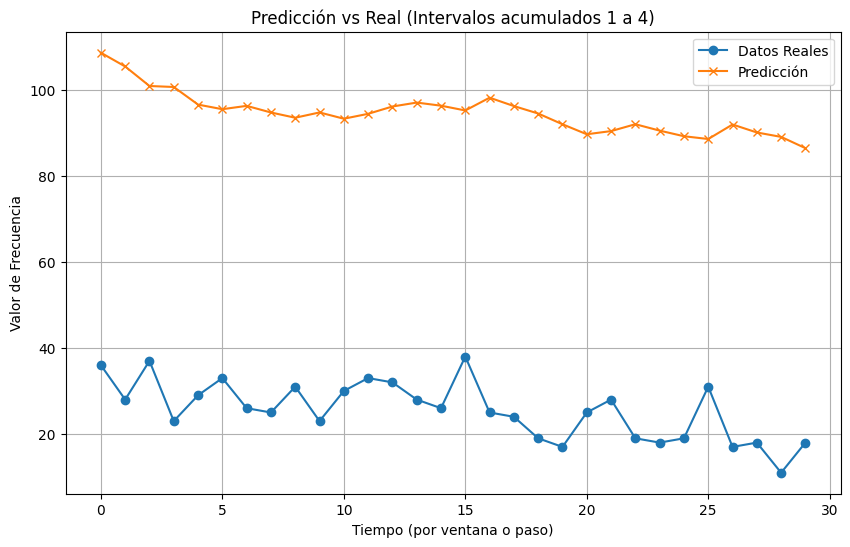

Iteración 5: Mejor época = 17, Loss = 0.1861
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Acumulando intervalos 1 a 5: MAE = 94.29, MSE = 17007.17


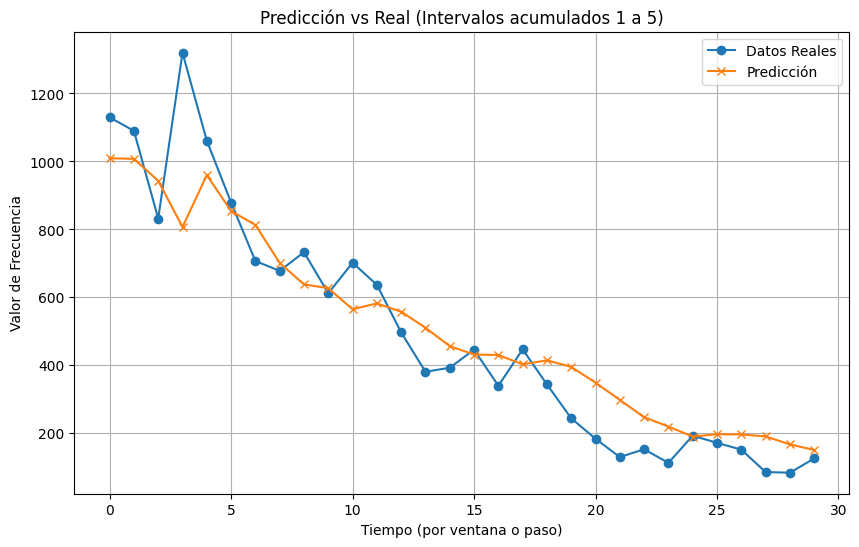

Iteración 6: Mejor época = 6, Loss = 0.2173
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Acumulando intervalos 1 a 6: MAE = 54.76, MSE = 3448.40


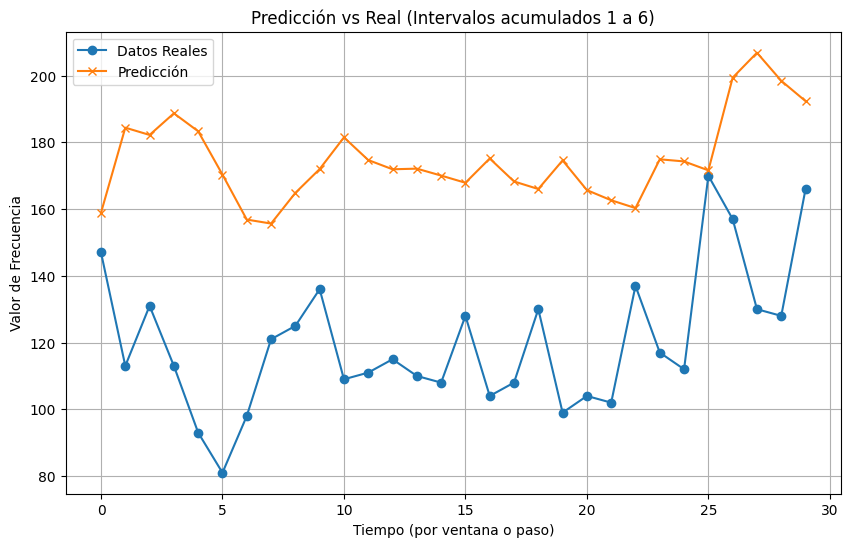

Iteración 7: Mejor época = 24, Loss = 0.1552
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 7: MAE = 49.26, MSE = 2561.48


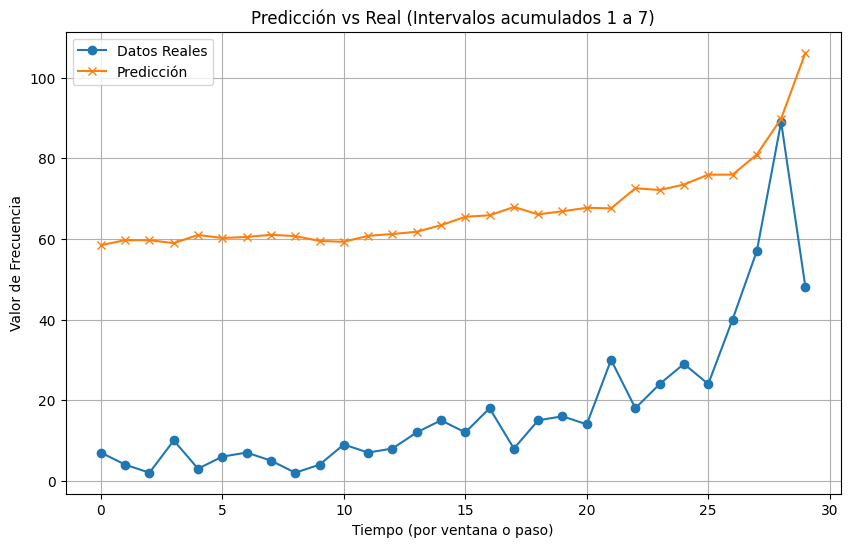

Iteración 8: Mejor época = 22, Loss = 0.1681
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Acumulando intervalos 1 a 8: MAE = 47.28, MSE = 2244.48


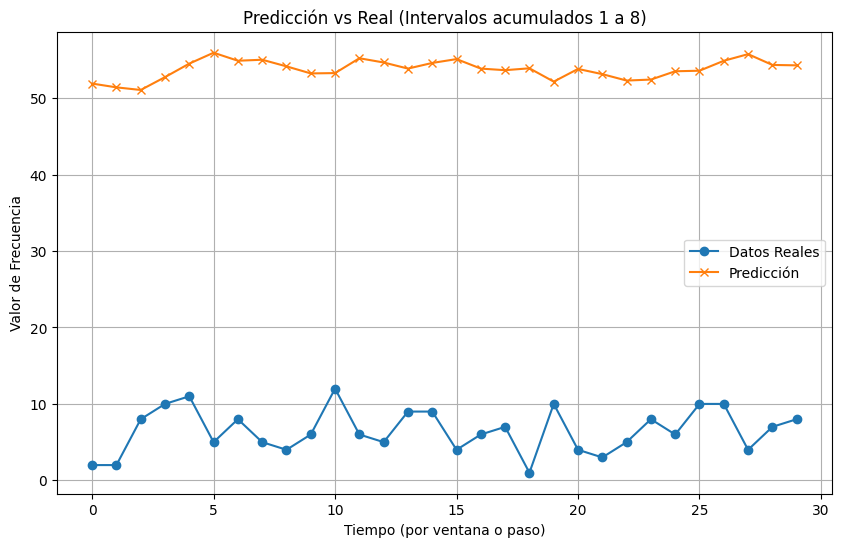


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   91.780246  12082.631769   48.952478
1      Intervalos 1 a 2   90.960640  14605.490754   20.245272
2      Intervalos 1 a 3  198.198497  70278.248815   27.547113
3      Intervalos 1 a 4   69.035353   4798.948015  116.029866
4      Intervalos 1 a 5   94.288681  17007.168392   25.602763
5      Intervalos 1 a 6   54.761079   3448.402483   37.996650
6      Intervalos 1 a 7   49.260412   2561.483915  128.881528
7      Intervalos 1 a 8   47.275991   2244.476408  157.646475


In [23]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
# scaler = MinMaxScaler(feature_range=(0, 1))

scaler = StandardScaler()

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"14_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_5/lstm_14_30.csv', index=False)

### Train for windows size = 21


Iteración 1: Mejor época = 6, Loss = 0.0279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Acumulando intervalos 1 a 1: MAE = 63.05, MSE = 7659.86


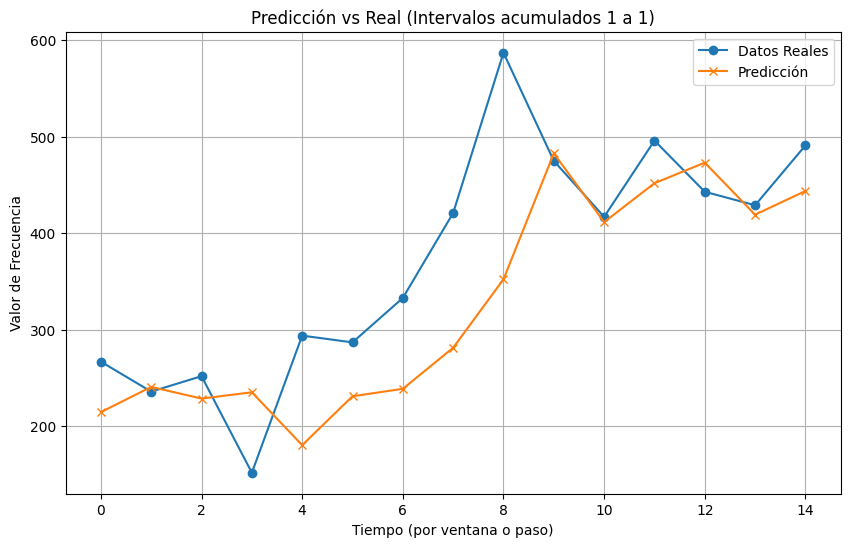

Iteración 2: Mejor época = 22, Loss = 0.1921
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Acumulando intervalos 1 a 2: MAE = 110.94, MSE = 19062.50


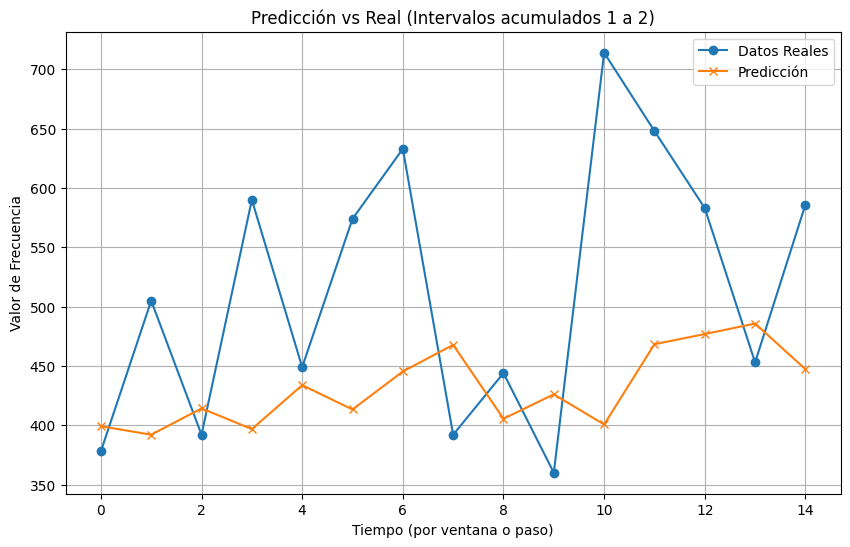

Iteración 3: Mejor época = 8, Loss = 0.1588
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 3: MAE = 292.76, MSE = 137508.53


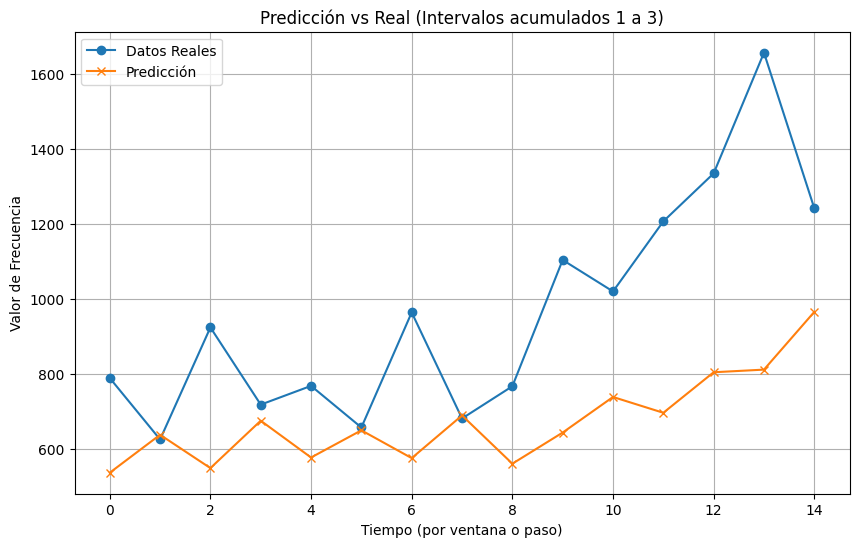

Iteración 4: Mejor época = 16, Loss = 0.1888
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 93.82, MSE = 8842.29


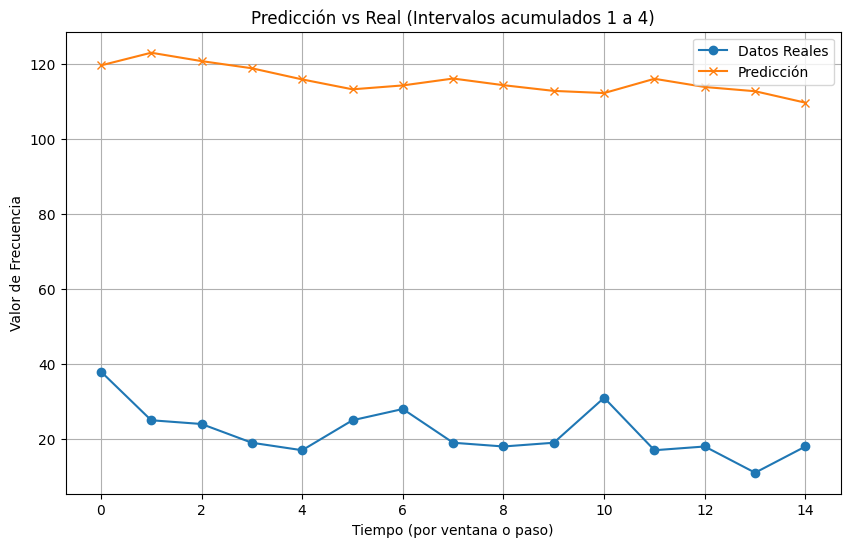

Iteración 5: Mejor época = 9, Loss = 0.2143
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 5: MAE = 65.13, MSE = 5645.40


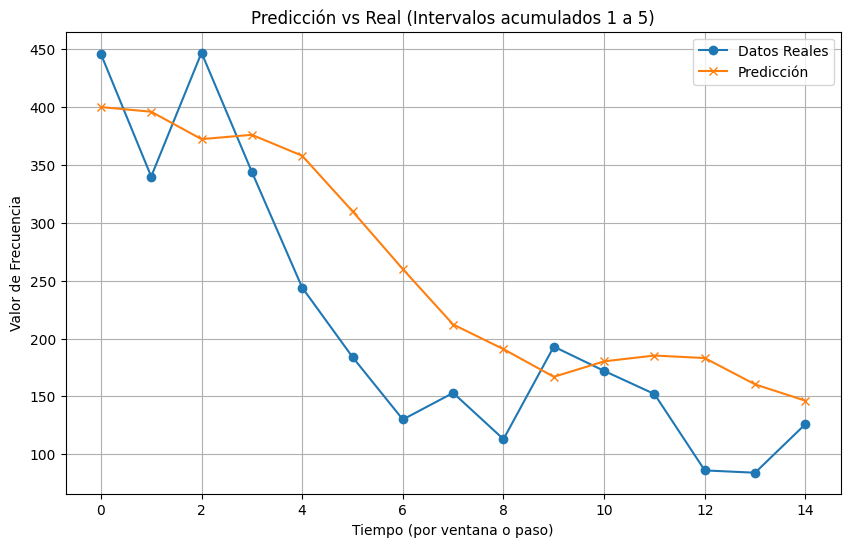

Iteración 6: Mejor época = 8, Loss = 0.1773
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 6: MAE = 38.62, MSE = 1805.90


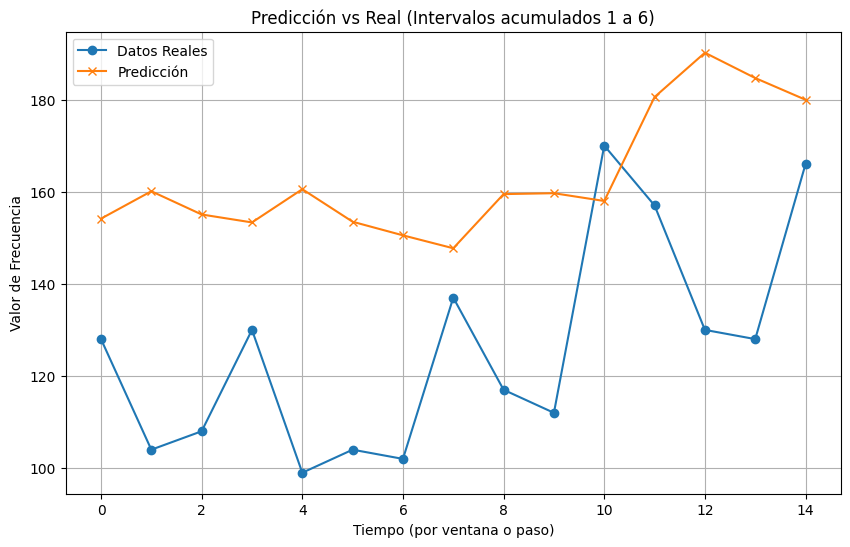

Iteración 7: Mejor época = 9, Loss = 0.1923
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 7: MAE = 58.61, MSE = 3642.50


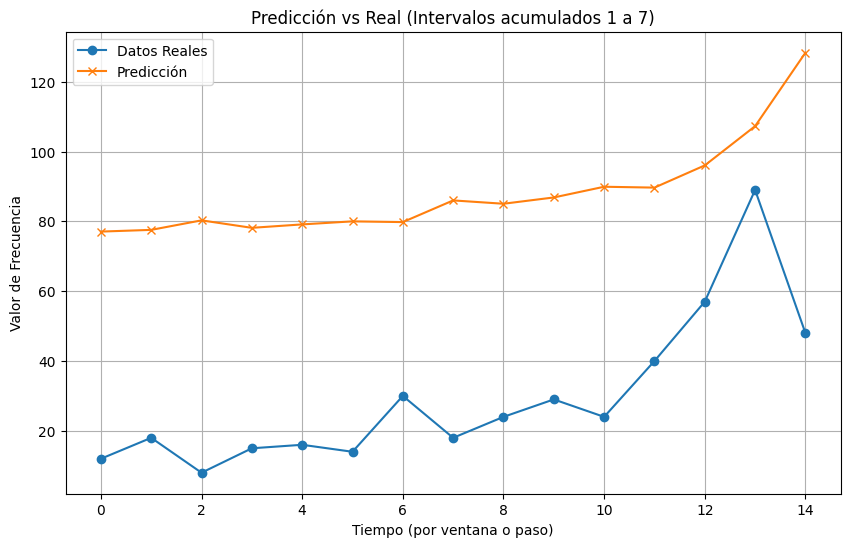

Iteración 8: Mejor época = 12, Loss = 0.1825
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 8: MAE = 41.43, MSE = 1725.84


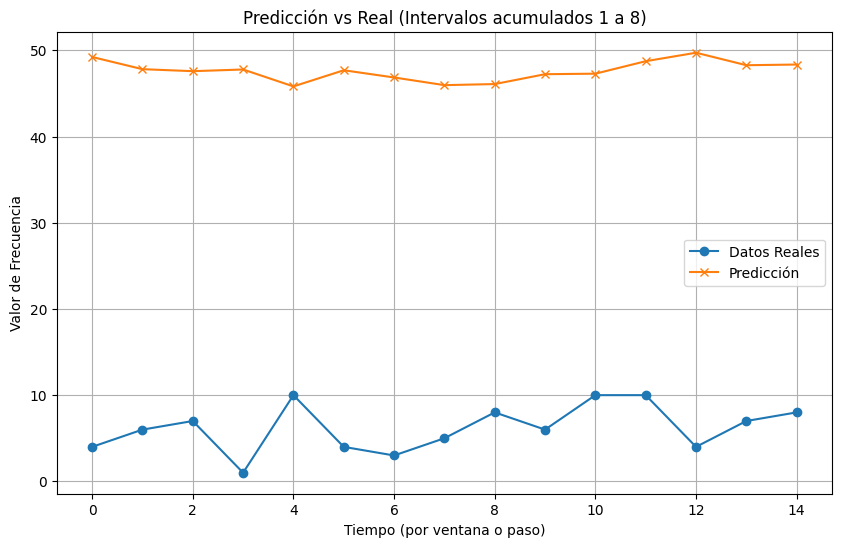


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   63.045696    7659.860988   19.973549
1      Intervalos 1 a 2  110.937207   19062.500730   22.124603
2      Intervalos 1 a 3  292.758842  137508.528023   32.750503
3      Intervalos 1 a 4   93.820783    8842.289152  137.344068
4      Intervalos 1 a 5   65.126894    5645.402861   32.054605
5      Intervalos 1 a 6   38.620841    1805.902008   27.602113
6      Intervalos 1 a 7   58.609039    3642.496949  108.644635
7      Intervalos 1 a 8   41.429292    1725.838561  154.702327


In [24]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
# scaler = MinMaxScaler(feature_range=(0, 1))

scaler = StandardScaler()

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"21_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_5/lstm_21_15.csv', index=False)

Iteración 1: Mejor época = 32, Loss = 0.0038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Acumulando intervalos 1 a 1: MAE = 84.29, MSE = 11347.86


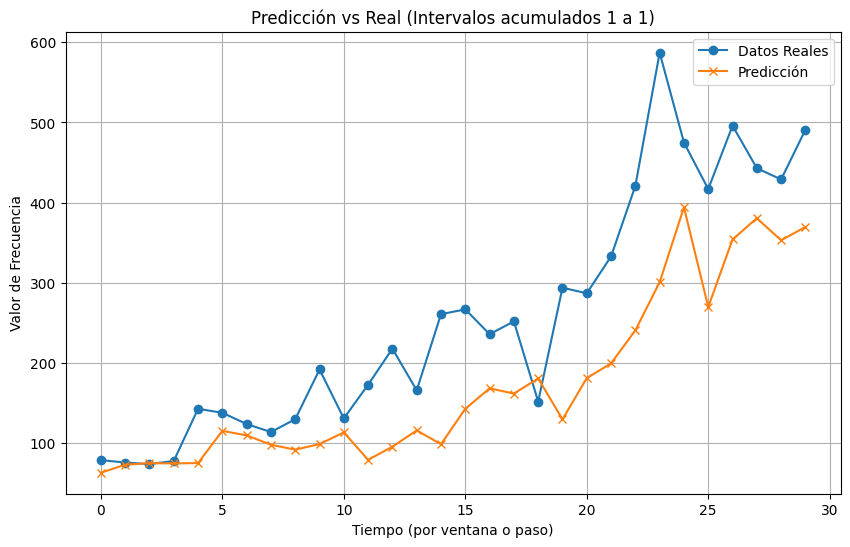

Iteración 2: Mejor época = 6, Loss = 0.1949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 2: MAE = 85.83, MSE = 11949.30


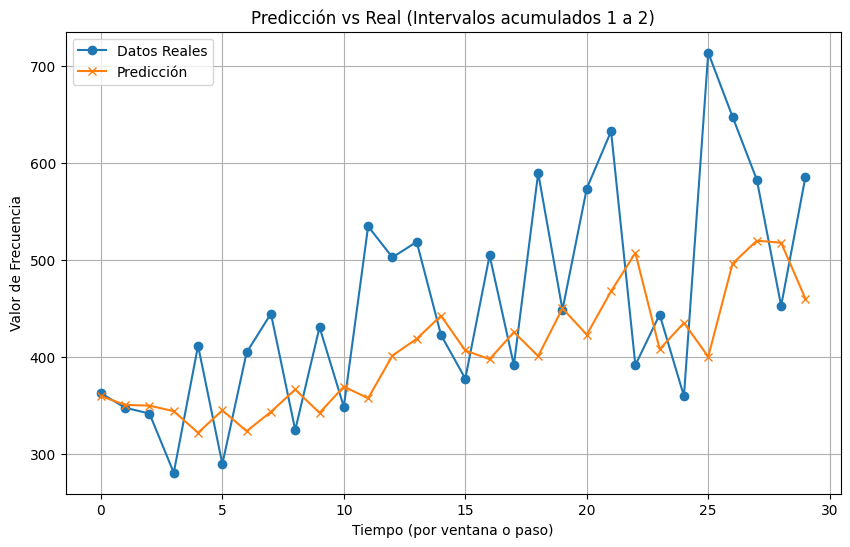

Iteración 3: Mejor época = 3, Loss = 0.1591
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Acumulando intervalos 1 a 3: MAE = 207.92, MSE = 76340.54


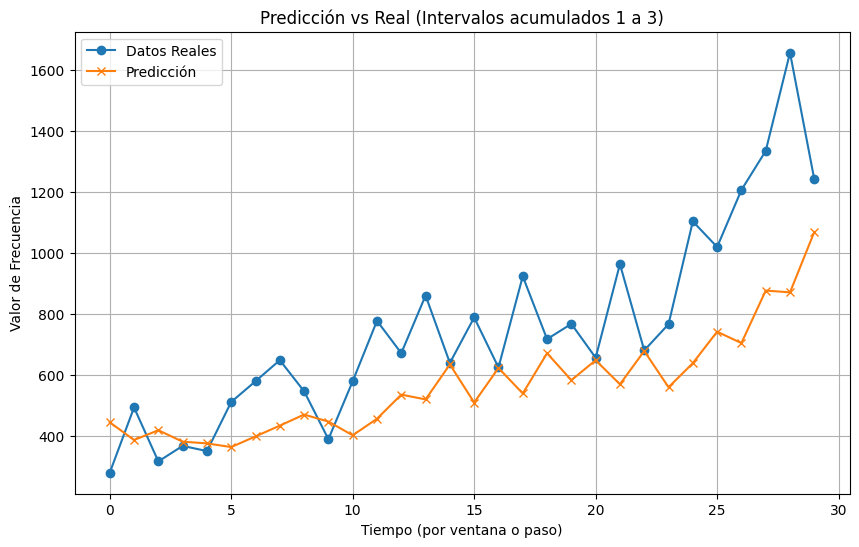

Iteración 4: Mejor época = 3, Loss = 0.1456
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 92.63, MSE = 8613.47


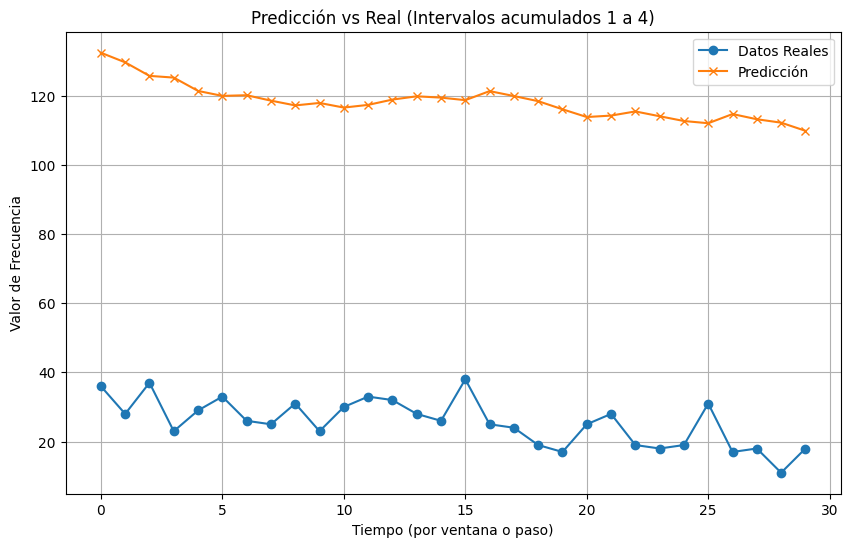

Iteración 5: Mejor época = 5, Loss = 0.1712
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Acumulando intervalos 1 a 5: MAE = 80.18, MSE = 11843.90


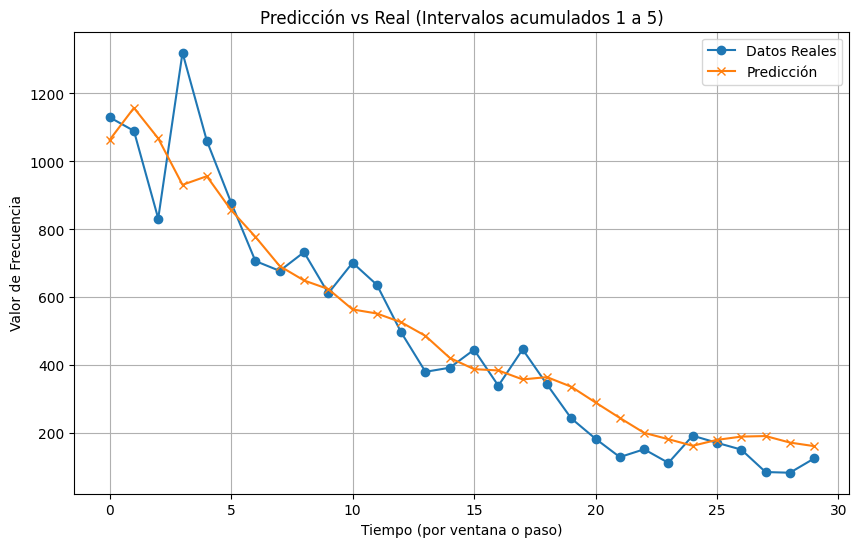

Iteración 6: Mejor época = 10, Loss = 0.1690
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Acumulando intervalos 1 a 6: MAE = 62.30, MSE = 4317.11


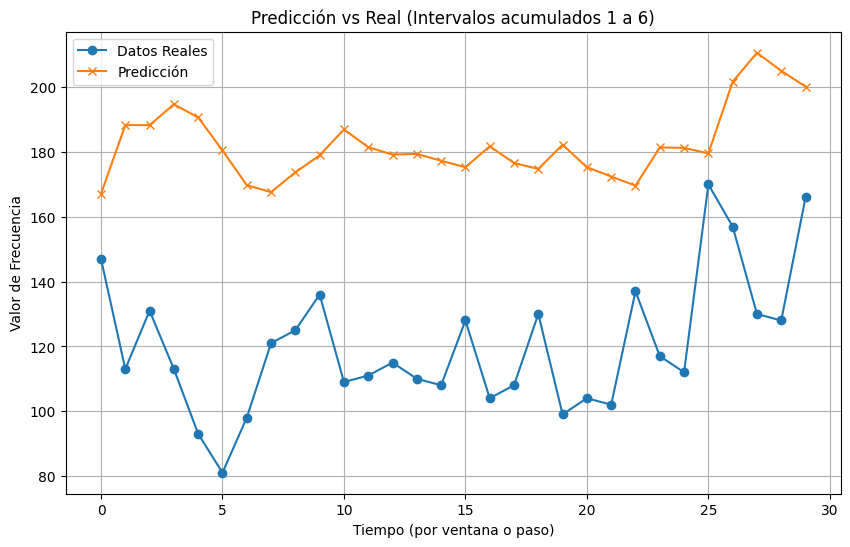

Iteración 7: Mejor época = 6, Loss = 0.2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Acumulando intervalos 1 a 7: MAE = 46.16, MSE = 2255.77


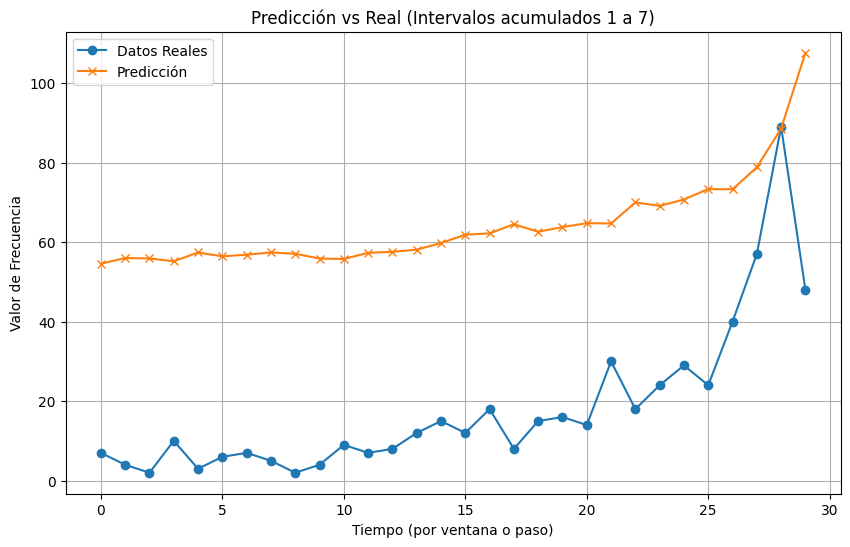

Iteración 8: Mejor época = 9, Loss = 0.1562
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Acumulando intervalos 1 a 8: MAE = 58.38, MSE = 3417.35


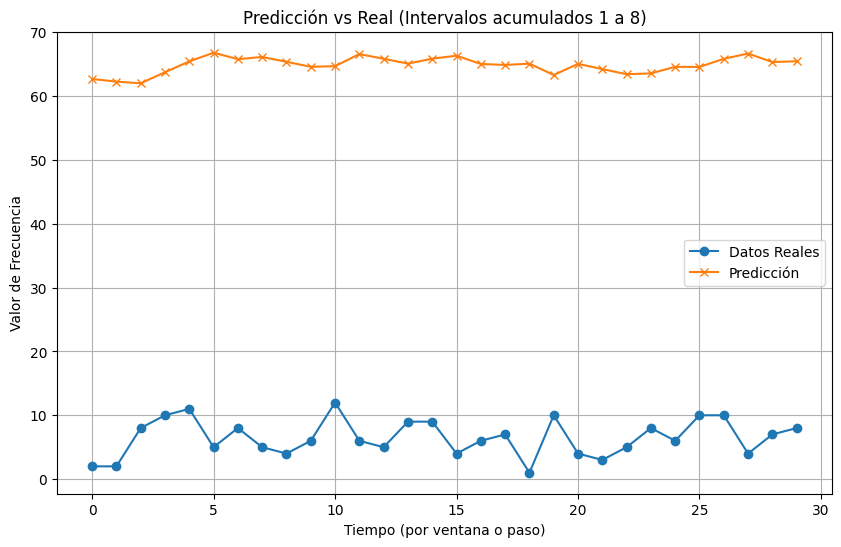


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   84.286220  11347.855481   37.742080
1      Intervalos 1 a 2   85.832078  11949.302262   18.843198
2      Intervalos 1 a 3  207.919994  76340.538022   29.250670
3      Intervalos 1 a 4   92.628604   8613.465041  129.723780
4      Intervalos 1 a 5   80.176237  11843.899481   22.154921
5      Intervalos 1 a 6   62.303704   4317.110517   42.097025
6      Intervalos 1 a 7   46.158614   2255.774547  126.510078
7      Intervalos 1 a 8   58.377489   3417.345913  164.145629


In [25]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 30
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
# scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"21_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_5/lstm_21_30.csv', index=False)